In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
from metpy.calc import wet_bulb_temperature
from metpy.units import units
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

from config_snobal import * #restart kernel if you update config file!

In [2]:
print(f"...PROCESSING WATER YEAR:' {water_year}")

...PROCESSING WATER YEAR:' 2026


#### Open raw forcing files (4 files total)

    precip             --> 150inDruck_Prcp_hourly.csv (3000mm_Geo_Prcp_15MinAvg.dat--> too messy right now)
    manual_obs         --> manual_observations_WY2025.csv
    flux               --> S2S1_Flux_CSFormat.dat
    met                --> S2S1_Met_data.dat

##### Workflow process
- Ensure complete timeseries (reindex)
- Remove bad values (threshold filters, despiking)
- Gap fill (diurnal_fill)
- Resample to hourly
- Compute derived variables

##### snow notes...
3/26 - I think all but the manual snow data are in UTC. However, they are daily measurements and when downsampled you can just assume UTC since time doesn't matter.

#### 150inDruck_Prcp_hourly.csv
- precip

In [3]:
# Path to your data file
filepath = basepath / file_precip

# Read the data using pandas
df_precip = pd.read_csv(
    filepath,
    parse_dates={'Timestamp': ['Date', 'Time']},
    dayfirst=False,  
    na_values=-99.9
)
# set the index
df_precip.set_index('Timestamp', inplace=True)

# convert to mm from inches
df_precip['PRCP mm'] = df_precip['PREC.I-1 (in) '] *25.4

# Reindex to a complete hourly time series (no missing hours)
full_index = pd.date_range(start=start_date, end=end_date, freq='h')
df_precip = df_precip.reindex(full_index)
df_precip.index.name = 'datetime'

# Linear interpolation to gap-fill missing values (gaps really are only in the beginnig of the year at 0, so this is okay for now)
df_precip['PRCP mm'] = df_precip['PRCP mm'].interpolate(method='linear', limit_area='inside')

# ensure data are increasing or the same (e.g. 1, 1, 1.1, 1, 1.1 --> 1, 1, 1.1, 1.1, 1.1)
df_precip['PRCP mm'] = df_precip['PRCP mm'].cummax()

df_prcp_1h = df_precip.copy()

df_prcp_1h.head()



/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_18366/462045125.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_precip = pd.read_csv(
/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_18366/462045125.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_precip = pd.read_csv(


,PREC.I-1 (in),PRCP mm
datetime,,
2025-10-01 00:00:00,0.0,0.00
2025-10-01 01:00:00,0.0,0.00
2025-10-01 02:00:00,0.1,2.54
2025-10-01 03:00:00,0.1,2.54
2025-10-01 04:00:00,0.1,2.54


Text(0, 0.5, 'ACCUM PRECIP [mm]')

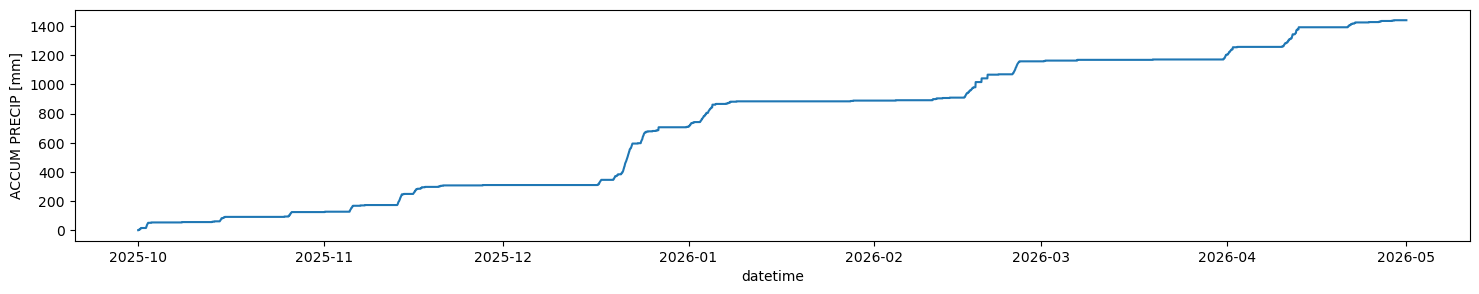

In [4]:
fig = plt.figure(figsize=(18, 3))
plt.plot(df_prcp_1h.index, df_prcp_1h['PRCP mm'])
plt.xlabel('datetime')
plt.ylabel('ACCUM PRECIP [mm]')

In [5]:
# specific to this case

# compute incremental precip from accumulated 
df_prcp_1h['PRCP mm incremental'] = df_prcp_1h['PRCP mm'].diff().fillna(0)

Text(0, 0.5, 'INCREMENTAL PRECIP [mm]')

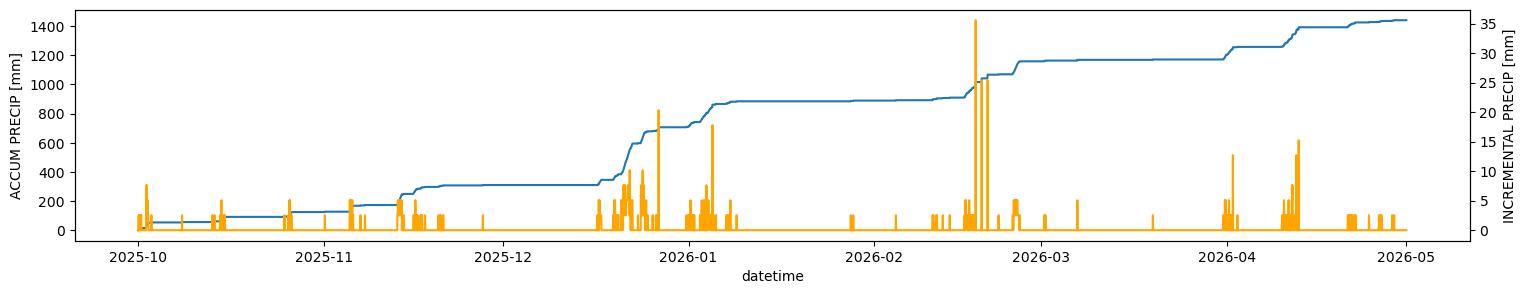

In [6]:
fig, ax1 = plt.subplots(figsize=(18, 3))
ax1.plot(df_prcp_1h.index, df_prcp_1h['PRCP mm'], label='Accumulated')
ax1.set_xlabel('datetime')
ax1.set_ylabel('ACCUM PRECIP [mm]')

ax2 = ax1.twinx()
ax2.plot(df_prcp_1h.index, df_prcp_1h['PRCP mm incremental'], color='orange', label='Incremental')
ax2.set_ylabel('INCREMENTAL PRECIP [mm]')

# plot

#### manual_observations_WY2025.csv
- percent_snow
- snow_density

In [7]:
# Path to your data file
filepath = basepath / file_manual_obs

df_man = pd.read_csv(filepath, parse_dates=["Date"], na_values='--')

df_man['Snowpack depth (cm)'] = pd.to_numeric(df_man['Snowpack depth (cm)'], errors='coerce')

df_man = df_man.set_index("Date")

# Ensure complete daily time series
full_index = pd.date_range(start=start_date, end=end_date, freq='D')
df_man = df_man.reindex(full_index)
df_man.index.name = 'datetime'


/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_18366/500870780.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_man = pd.read_csv(filepath, parse_dates=["Date"], na_values='--')


In [8]:
# stuff specific to this application

# convert % to decimal %
df_man["Percent Snow"] = df_man["% of Precip as Snow"]/100


df_man["Percent Snow"] = df_man["Percent Snow"].fillna(0)

# compute NEW snow density (SWE cm / depth cm)
df_man["Snow Density"] = df_man["Snow Water Equivalent (cm)"]/ df_man["New Snow (cm)"] *1000

# Fill NaNs w/ Zero
df_man["Snow Density"] = df_man["Snow Density"].fillna(0)

df_man.head()


,Air Temp Max (C),Air Temp Min (C),24-hour Total Precip (mm),Season Total Precip (mm),% of Precip as Snow,% of Precip as Rain,New Snow (cm),Season Total Snow (cm),Snowpack depth (cm),Snow Water Equivalent (cm),Remarks,is_fallback,Percent Snow,Snow Density
datetime,,,,,,,,,,,,,,
2025-10-01,NaN,NaN,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,NaN,f,0.0,0.0
2025-10-02,NaN,NaN,15.0,15.0,0.0,100.0,0.0,0.0,0.0,0.0,NaN,f,0.0,0.0
2025-10-03,NaN,NaN,36.0,51.0,0.0,100.0,0.0,0.0,0.0,0.0,NaN,f,0.0,0.0
2025-10-04,NaN,NaN,2.0,53.0,0.0,100.0,0.0,0.0,0.0,0.0,NaN,f,0.0,0.0
2025-10-05,NaN,NaN,0.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,f,0.0,0.0


In [9]:
print(df_man.columns)

Index(['Air Temp Max (C)', 'Air Temp Min (C)', '24-hour Total Precip (mm)',
       'Season Total Precip (mm)', '% of Precip as Snow',
       '% of Precip as Rain', 'New Snow (cm)', 'Season Total Snow (cm)',
       'Snowpack depth (cm)', 'Snow Water Equivalent (cm)', 'Remarks',
       'is_fallback', 'Percent Snow', 'Snow Density'],
      dtype='object')


In [10]:
# upsample to hourly from daily
df_man_1h = df_man[["Percent Snow", "Snow Density"]].resample("1h").ffill() # upsample and fill value for all hours (remove later when compared to precip?)
df_man_1h.head()

,Percent Snow,Snow Density
datetime,,
2025-10-01 00:00:00,0.0,0.0
2025-10-01 01:00:00,0.0,0.0
2025-10-01 02:00:00,0.0,0.0
2025-10-01 03:00:00,0.0,0.0
2025-10-01 04:00:00,0.0,0.0


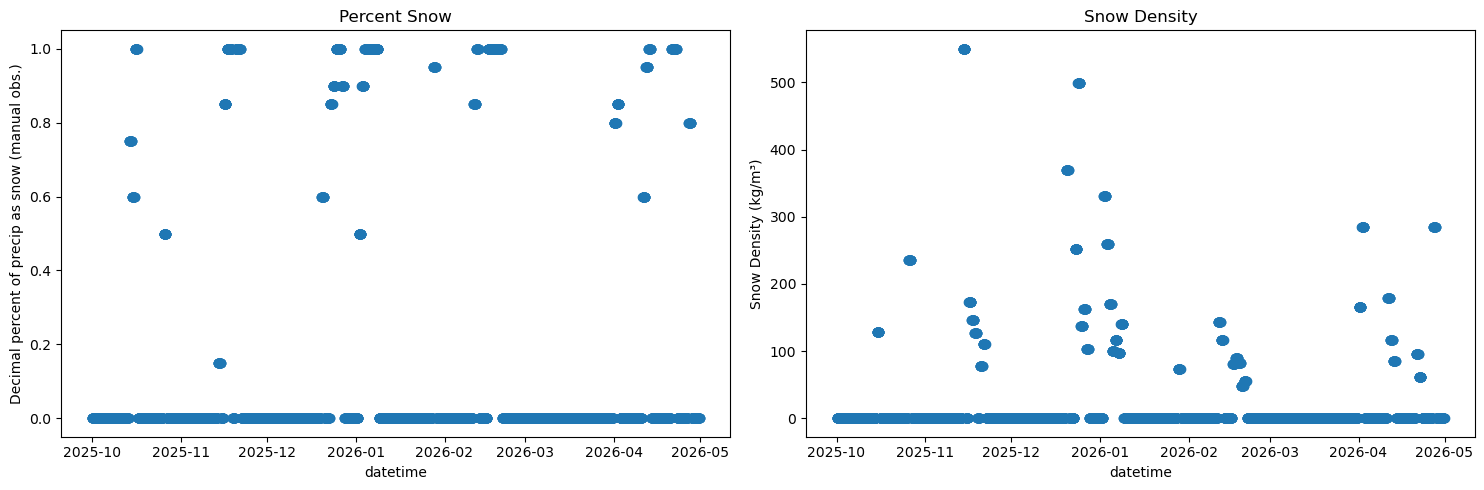

In [11]:
# PLOT IT - hourly % as snow

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Percent Snow
axes[0].scatter(df_man_1h.index, df_man_1h["Percent Snow"])
axes[0].set_xlabel("datetime")
axes[0].set_ylabel("Decimal percent of precip as snow (manual obs.)")
axes[0].set_title("Percent Snow")

# Snow Density
axes[1].scatter(df_man_1h.index, df_man_1h["Snow Density"])
axes[1].set_xlabel("datetime")
axes[1].set_ylabel("Snow Density (kg/m³)")
axes[1].set_title("Snow Density")

'''New snow density seems a little high to me, could review data and methods to compute, but all early season and quick look matches 25wy file'''

plt.tight_layout()
plt.show()


#### S2S1_Flux_CSFormat.dat
- air temp (CHEDDAR arm)
- vapor pressure

In [12]:
# Path to your data file
filepath = basepath / file_flux

# Read the lines manually first
with open(filepath, 'r') as f:
    lines = f.readlines()

# Extract the relevant header rows
column_names = next((line for line in lines if line.startswith('"TIMESTAMP')), None)
units = next((line for line in lines if '"TS"' in line), None)

# Split and strip quotes
column_names = [name.strip('"') for name in column_names.strip().split(',')]
units = [unit.strip('"') for unit in units.strip().split(',')]

# Combine name and unit
combined_headers = [
    f"{name} ({unit})" if unit else name
    for name, unit in zip(column_names, units)
]

# Read the data using pandas, skipping the first 4 rows
df_flux = pd.read_csv(filepath, skiprows=4, names=combined_headers, parse_dates=["TIMESTAMP (TS)"])

# Set the index
df_flux.set_index("TIMESTAMP (TS)", inplace=True)

# Drop duplicate timestamps, keeping the first occurrence
df_flux = df_flux[~df_flux.index.duplicated(keep='first')]

# Ensure complete 30-min time series
full_index = pd.date_range(start=start_date, end=end_date, freq='30min')
df_flux = df_flux.reindex(full_index)
df_flux.index.name = 'datetime'

# Sanity check
print(f"Missing timestamps: {df_flux.index[df_flux.isnull().all(axis=1)].tolist()}")

# Format data type
df_flux = df_flux.apply(pd.to_numeric, errors='coerce')



/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_18366/708121000.py:23: DtypeWarning: Columns (11,13,21,31,37,61,62,66,67,69,76,77,78,79,80,81,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flux = pd.read_csv(filepath, skiprows=4, names=combined_headers, parse_dates=["TIMESTAMP (TS)"])


Missing timestamps: [Timestamp('2025-10-30 23:00:00'), Timestamp('2025-12-17 04:00:00'), Timestamp('2025-12-17 04:30:00'), Timestamp('2025-12-17 05:00:00'), Timestamp('2025-12-17 05:30:00'), Timestamp('2025-12-17 06:00:00'), Timestamp('2025-12-17 06:30:00'), Timestamp('2025-12-17 07:00:00'), Timestamp('2025-12-17 07:30:00'), Timestamp('2025-12-17 08:00:00'), Timestamp('2025-12-17 08:30:00'), Timestamp('2025-12-17 09:00:00'), Timestamp('2025-12-17 09:30:00'), Timestamp('2025-12-17 10:00:00'), Timestamp('2025-12-17 10:30:00'), Timestamp('2025-12-17 11:00:00'), Timestamp('2025-12-17 11:30:00'), Timestamp('2025-12-17 12:00:00'), Timestamp('2025-12-17 12:30:00'), Timestamp('2025-12-17 13:00:00'), Timestamp('2025-12-17 13:30:00'), Timestamp('2025-12-17 14:00:00'), Timestamp('2025-12-17 14:30:00'), Timestamp('2025-12-17 15:00:00'), Timestamp('2025-12-17 15:30:00'), Timestamp('2025-12-17 16:00:00'), Timestamp('2025-12-17 16:30:00'), Timestamp('2025-12-17 17:00:00'), Timestamp('2025-12-17 17:30

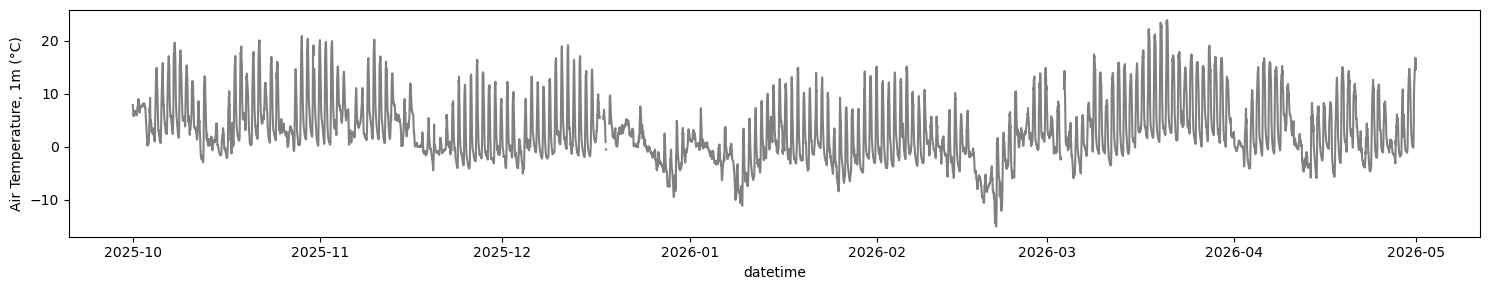

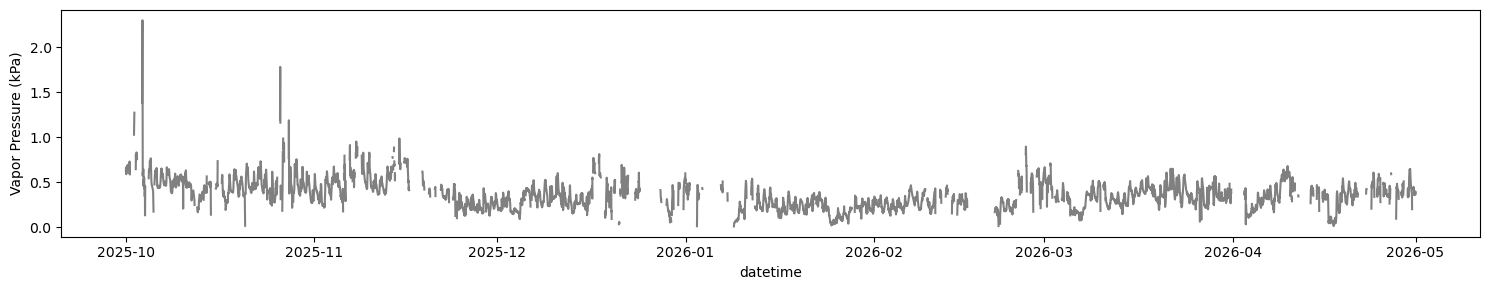

'Notes\nVapor Pressure, common values are XX-XX kPa for XXXXX, set threshold to remove >1.5 right now?\n\n\n\n'

In [13]:
def plot_single(df, col, ylabel, color='gray', figsize=(15, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df[col], color=color)
    ax.set_xlabel('datetime')
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# air temp
plot_single(df_flux, 'TA_1_1_1 (deg C)', 'Air Temperature, 1m (°C)')

# vapor pressure
plot_single(df_flux, 'e_amb (kPa)', 'Vapor Pressure (kPa)')

'''Notes
Vapor Pressure, common values are XX-XX kPa for XXXXX, set threshold to remove >1.5 right now?



'''

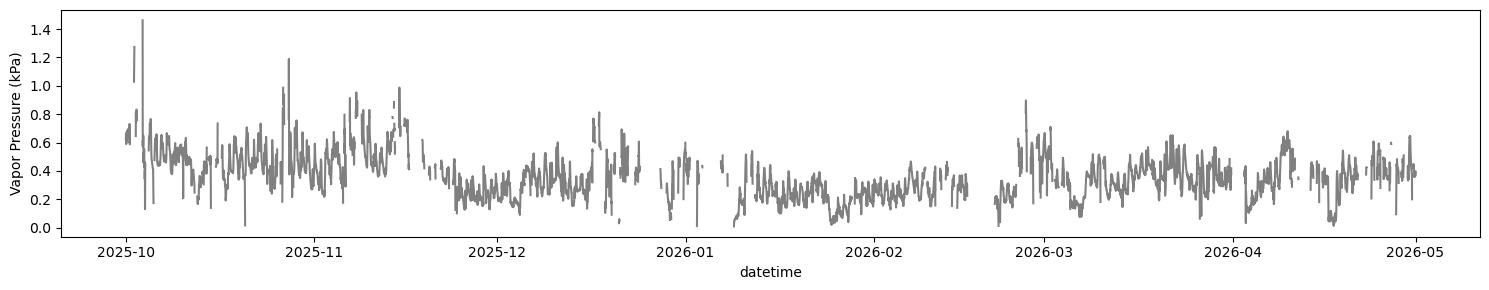

In [14]:
# specialized clean up:

# vapor pressure
df_flux.loc[df_flux['e_amb (kPa)'] > vapor_pressure_max_kpa, 'e_amb (kPa)'] = np.nan

plot_single(df_flux, 'e_amb (kPa)', 'Vapor Pressure (kPa)')

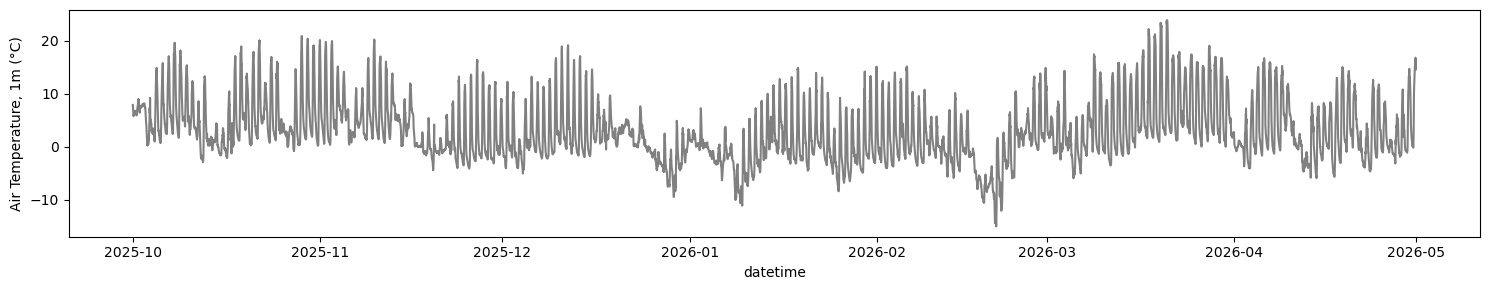

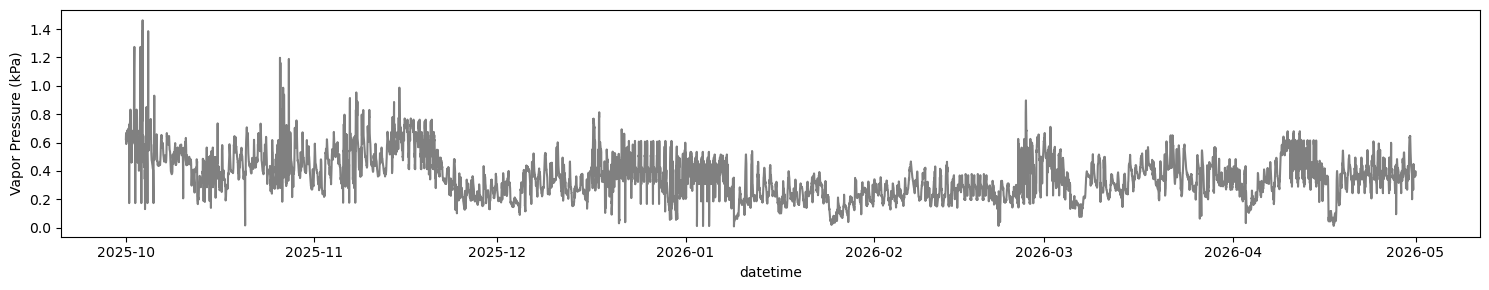

In [15]:
def diurnal_fill(series, max_days=diurnal_fill_max_days): 
    """Fill NaNs by looking at the same hour n days before/after, increasing n until filled."""
    filled = series.copy()
    
    for n in range(1, max_days + 1):
        nan_mask = filled.isna()
        if not nan_mask.any():
            break
        for ts in filled.index[nan_mask]:
            before = filled.get(ts - pd.Timedelta(days=n))
            after  = filled.get(ts + pd.Timedelta(days=n))
            values = [v for v in [before, after] if pd.notna(v)]
            if values:
                filled[ts] = np.mean(values)
    
    return filled

df_flux = df_flux.apply(lambda col: diurnal_fill(col, max_days=diurnal_fill_max_days))

# air temp
plot_single(df_flux, 'TA_1_1_1 (deg C)', 'Air Temperature, 1m (°C)')
# vapor pressure
plot_single(df_flux, 'e_amb (kPa)', 'Vapor Pressure (kPa)')

In [16]:
# specific to this use case

# convert to Pa (Pascal) from kPa (kiloPascal)
df_flux['e_amb (Pa)'] = df_flux['e_amb (kPa)'] *1000

# downsample to 1 hour from 30 min
df_flux_1h = df_flux[['TA_1_1_1 (deg C)', 'e_amb (Pa)']].resample("1h").mean()

df_flux_1h.head()

,TA_1_1_1 (deg C),e_amb (Pa)
datetime,,
2025-10-01 00:00:00,7.698746,640.36880
2025-10-01 01:00:00,6.784641,623.37535
2025-10-01 02:00:00,5.927071,635.96040
2025-10-01 03:00:00,5.860375,669.35275
2025-10-01 04:00:00,6.139449,668.56355


#### S2S1_Met_data.dat
- air_temp (CAUTION, watch for bad values)
- wind_speed
- soil_temp
- net_solar
- thermal (incomming)
- precip_temp - calculated

In [17]:
# Path to your data file
filepath = basepath / file_met

# Read the lines manually first
with open(filepath, 'r') as f:
    lines = f.readlines()

# Extract the relevant header rows
column_names = next((line for line in lines if line.startswith('"TIMESTAMP')), None)
units = next((line for line in lines if '"TS"' in line), None)

# Split and strip quotes
column_names = [name.strip('"') for name in column_names.strip().split(',')]
units = [unit.strip('"') for unit in units.strip().split(',')]

# Combine name and unit
combined_headers = [
    f"{name} ({unit})" if unit else name
    for name, unit in zip(column_names, units)
]

# Read the data using pandas, skipping the first 4 rows
df_met = pd.read_csv(filepath, skiprows=4, names=combined_headers, parse_dates=["TIMESTAMP (TS)"])

# Set the index
df_met.set_index("TIMESTAMP (TS)", inplace=True)

# Drop duplicate timestamps, keeping the first occurrence
df_met = df_met[~df_met.index.duplicated(keep='first')]

# Ensure complete 5-min time series
full_index = pd.date_range(start=start_date, end=end_date, freq='5min')
df_met = df_met.reindex(full_index)
df_met.index.name = 'datetime'

# Sanity check
print(f"Missing timestamps: {df_met.index[df_met.isnull().all(axis=1)].tolist()}")

# Format data type
df_met = df_met.apply(pd.to_numeric, errors='coerce')

/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_18366/1530224454.py:23: DtypeWarning: Columns (5,13,14,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_met = pd.read_csv(filepath, skiprows=4, names=combined_headers, parse_dates=["TIMESTAMP (TS)"])


Missing timestamps: [Timestamp('2025-10-30 22:50:00'), Timestamp('2025-10-30 22:55:00'), Timestamp('2025-10-30 23:00:00'), Timestamp('2025-10-30 23:05:00'), Timestamp('2025-10-30 23:10:00'), Timestamp('2025-12-17 03:55:00'), Timestamp('2025-12-17 04:00:00'), Timestamp('2025-12-17 04:05:00'), Timestamp('2025-12-17 04:10:00'), Timestamp('2025-12-17 04:15:00'), Timestamp('2025-12-17 04:20:00'), Timestamp('2025-12-17 04:25:00'), Timestamp('2025-12-17 04:30:00'), Timestamp('2025-12-17 04:35:00'), Timestamp('2025-12-17 04:40:00'), Timestamp('2025-12-17 04:45:00'), Timestamp('2025-12-17 04:50:00'), Timestamp('2025-12-17 04:55:00'), Timestamp('2025-12-17 05:00:00'), Timestamp('2025-12-17 05:05:00'), Timestamp('2025-12-17 05:10:00'), Timestamp('2025-12-17 05:15:00'), Timestamp('2025-12-17 05:20:00'), Timestamp('2025-12-17 05:25:00'), Timestamp('2025-12-17 05:30:00'), Timestamp('2025-12-17 05:35:00'), Timestamp('2025-12-17 05:40:00'), Timestamp('2025-12-17 05:45:00'), Timestamp('2025-12-17 05:50

In [18]:
print(df_met.columns)

Index(['RECORD (RN)', 'BP_CS100 (mbar)', 'T_probe (deg C)',
       'T_DP_Probe (deg C)', 'RH_probe (%)', 'WS_05108_mean (m/s)',
       'WS_05108_rslt (m/s)', 'WD_05108_mean (degrees)',
       'WD_05108_StdDev (degrees)', 'WS_05108_Max (m/s)', 'R_SW_in (W m-2)',
       'R_SW_out (W m-2)', 'R_LW_in (W m-2)', 'R_LW_out (W m-2)', 'albedo (%)',
       'METAR', 'VWC_5cm (m^3/m^3)', 'Ka_5cm (unitless)', 'T_5cm (Deg C)',
       'BulkEC_5cm (dS/m)', 'VWC_10cm (m^3/m^3)', 'Ka_10cm (unitless)',
       'T_10cm (Deg C)', 'BulkEC_10cm (dS/m)', 'VWC_20cm (m^3/m^3)',
       'Ka_20cm (unitless)', 'T_20cm (Deg C)', 'BulkEC_20cm (dS/m)',
       'VWC_30cm (m^3/m^3)', 'Ka_30cm (unitless)', 'T_30cm (Deg C)',
       'BulkEC_30cm (dS/m)', 'VWC_40cm (m^3/m^3)', 'Ka_40cm (unitless)',
       'T_40cm (Deg C)', 'BulkEC_40cm (dS/m)', 'VWC_50cm (m^3/m^3)',
       'Ka_50cm (unitless)', 'T_50cm (Deg C)', 'BulkEC_50cm (dS/m)',
       'VWC_60cm (m^3/m^3)', 'Ka_60cm (unitless)', 'T_60cm (Deg C)',
       'BulkEC_60cm (dS/

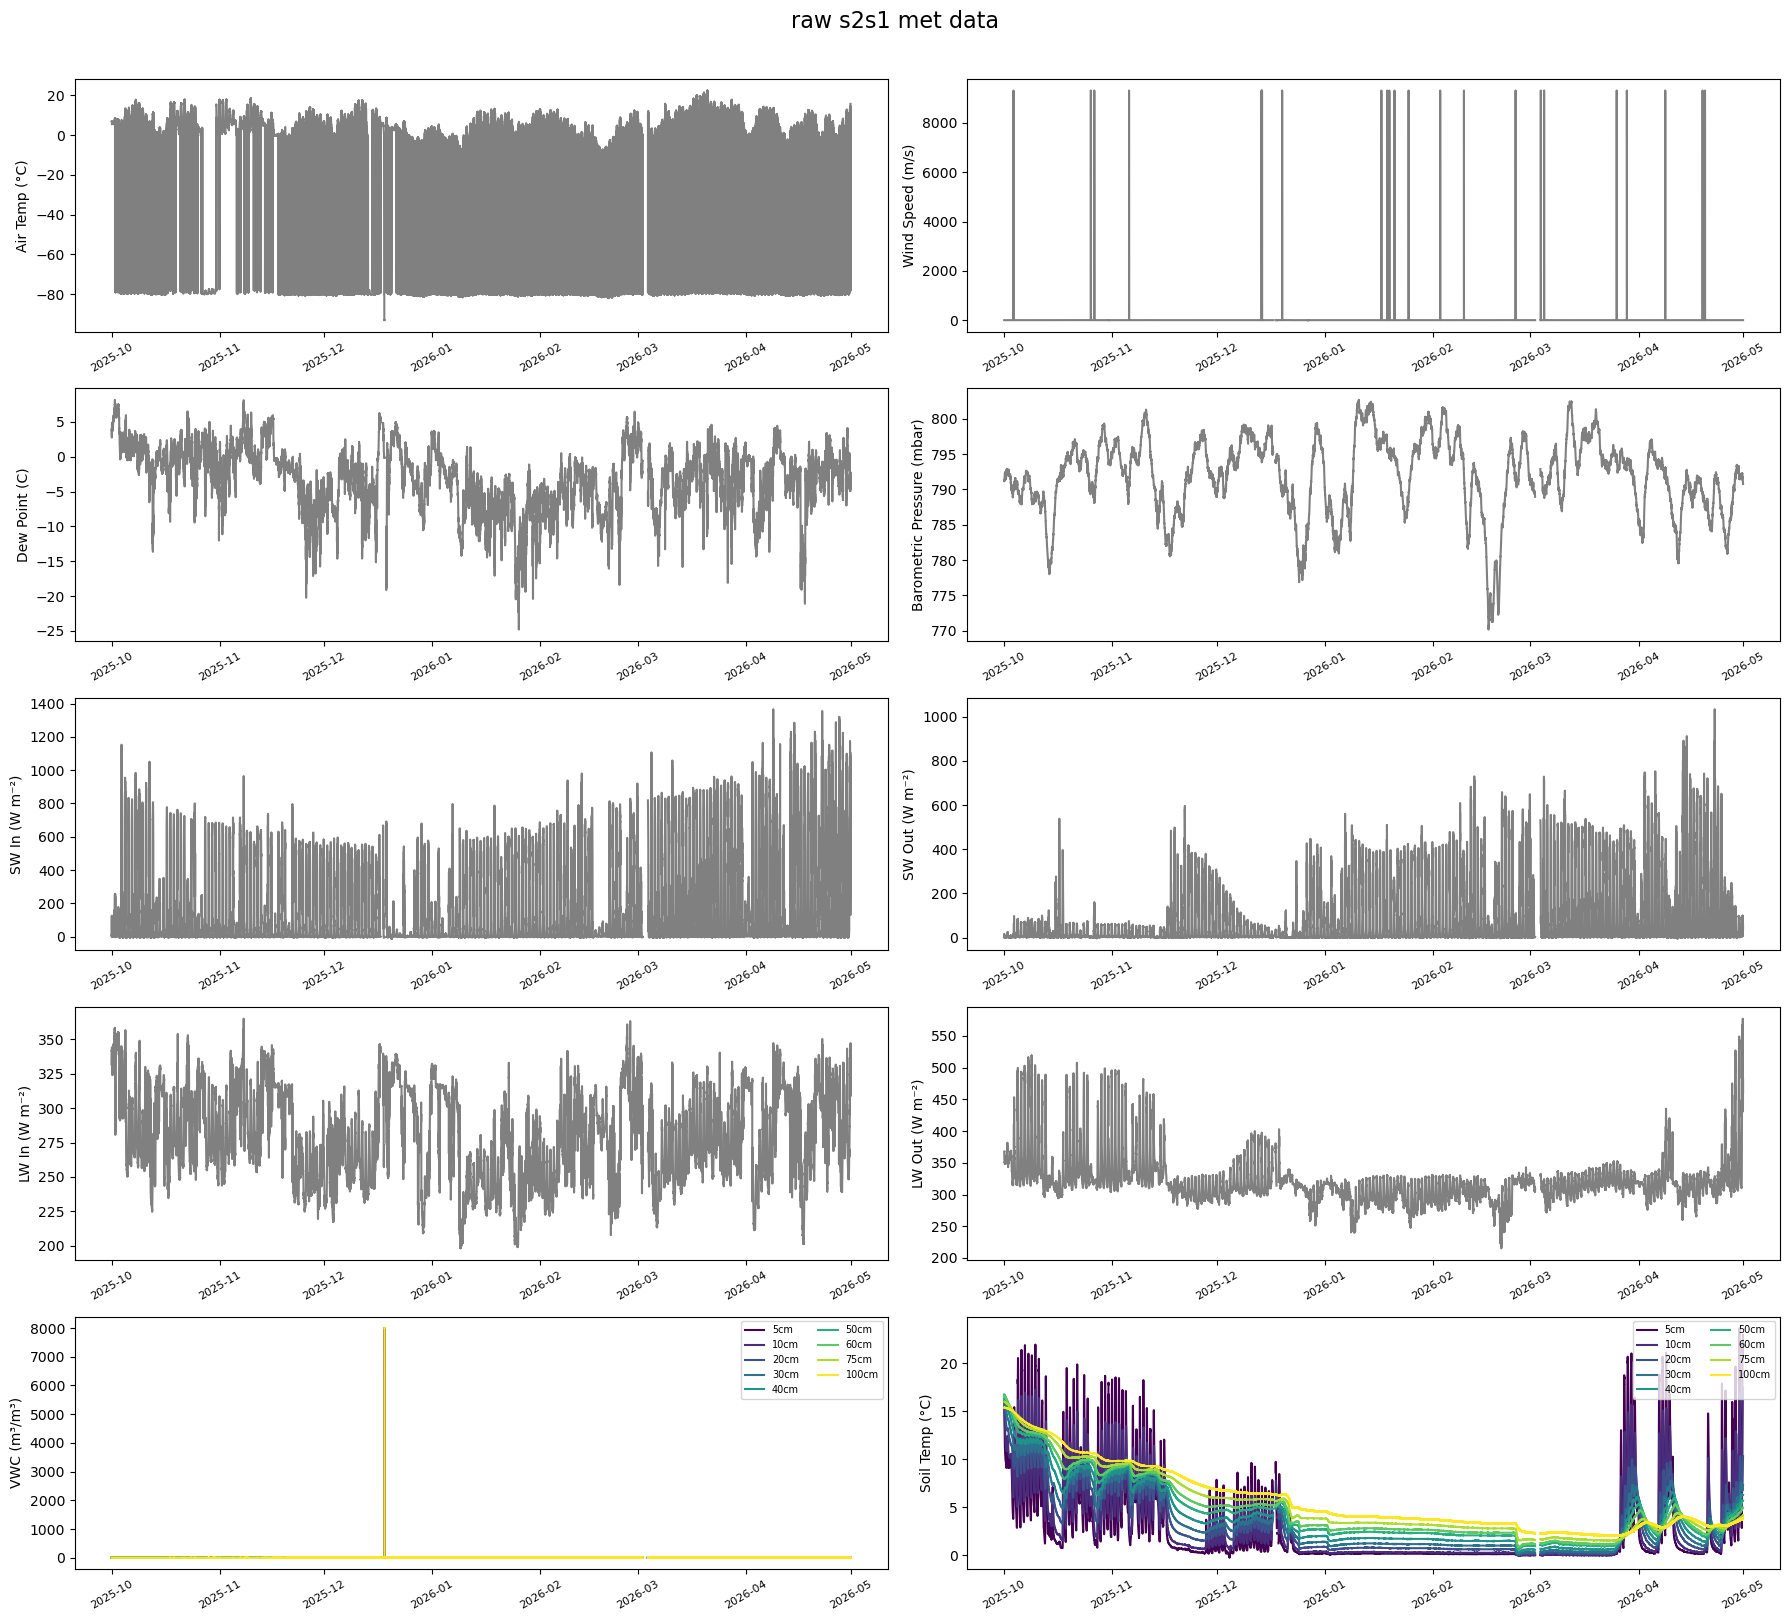

'\nNOTES\nAir Temp - lots of values at -80, something to do with the SoilVue affecting it, happens 2/3 of timestamps.. AND signal in general is muted, temps are too warm!\nWind Speed - safe to filter out everything >2500?\nBarometric Pressure - okay?\nDew Point - okay?\nSW in - okay?\nSW out - okay?\nLW in - okay\nLW out - okay\nVWC SM - okay\nSoil Temp - okay\n\n# raw plot\n\n'

In [19]:
def plot_met_overview(df, title, start=None, end=None):
    # Optionally slice to date range
    if start is not None or end is not None:
        df = df.loc[start:end]

    fig, axes = plt.subplots(5, 2, figsize=(18, 16))

    cmap = plt.cm.viridis
    depth_colors = [cmap(i / 8) for i in range(9)]
    depths = ['5cm', '10cm', '20cm', '30cm', '40cm', '50cm', '60cm', '75cm', '100cm']

    # Row 1
    axes[0, 0].plot(df.index, df['T_probe (deg C)'], color='gray')
    axes[0, 0].set_ylabel('Air Temp (°C)')

    axes[0, 1].plot(df.index, df['WS_05108_mean (m/s)'], color='gray')
    axes[0, 1].set_ylabel('Wind Speed (m/s)')

    # Row 2
    axes[1, 0].plot(df.index, df['T_DP_Probe (deg C)'], color='gray')
    axes[1, 0].set_ylabel('Dew Point (C)')

    axes[1, 1].plot(df.index, df['BP_CS100 (mbar)'], color='gray')
    axes[1, 1].set_ylabel('Barometric Pressure (mbar)')

    # Row 3
    axes[2, 0].plot(df.index, df['R_SW_in (W m-2)'], color='gray')
    axes[2, 0].set_ylabel('SW In (W m⁻²)')

    axes[2, 1].plot(df.index, df['R_SW_out (W m-2)'], color='gray')
    axes[2, 1].set_ylabel('SW Out (W m⁻²)')

    # Row 4
    axes[3, 0].plot(df.index, df['R_LW_in (W m-2)'], color='gray')
    axes[3, 0].set_ylabel('LW In (W m⁻²)')

    axes[3, 1].plot(df.index, df['R_LW_out (W m-2)'], color='gray')
    axes[3, 1].set_ylabel('LW Out (W m⁻²)')

    # Row 5 — soil moisture and soil temp, one line per depth
    for i, d in enumerate(depths):
        axes[4, 0].plot(df.index, df[f'VWC_{d} (m^3/m^3)'], color=depth_colors[i], label=d)
        axes[4, 1].plot(df.index, df[f'T_{d} (Deg C)'], color=depth_colors[i], label=d)

    axes[4, 0].set_ylabel('VWC (m³/m³)')
    axes[4, 1].set_ylabel('Soil Temp (°C)')
    axes[4, 0].legend(loc='upper right', fontsize=7, ncol=2)
    axes[4, 1].legend(loc='upper right', fontsize=7, ncol=2)

    # Shared formatting
    for ax in axes.flat:
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelrotation=30, labelsize=8)

    plt.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_met_overview(df_met, title='raw s2s1 met data')                                        # full range
# plot_met_overview(df_met, title='raw s2s1 met data', start='2025-5-20', end='2025-7-10')

'''
NOTES
Air Temp - lots of values at -80, something to do with the SoilVue affecting it, happens 2/3 of timestamps.. AND signal in general is muted, temps are too warm!
Wind Speed - safe to filter out everything >2500?
Barometric Pressure - okay?
Dew Point - okay?
SW in - okay?
SW out - okay?
LW in - okay
LW out - okay
VWC SM - okay
Soil Temp - okay

# raw plot

'''

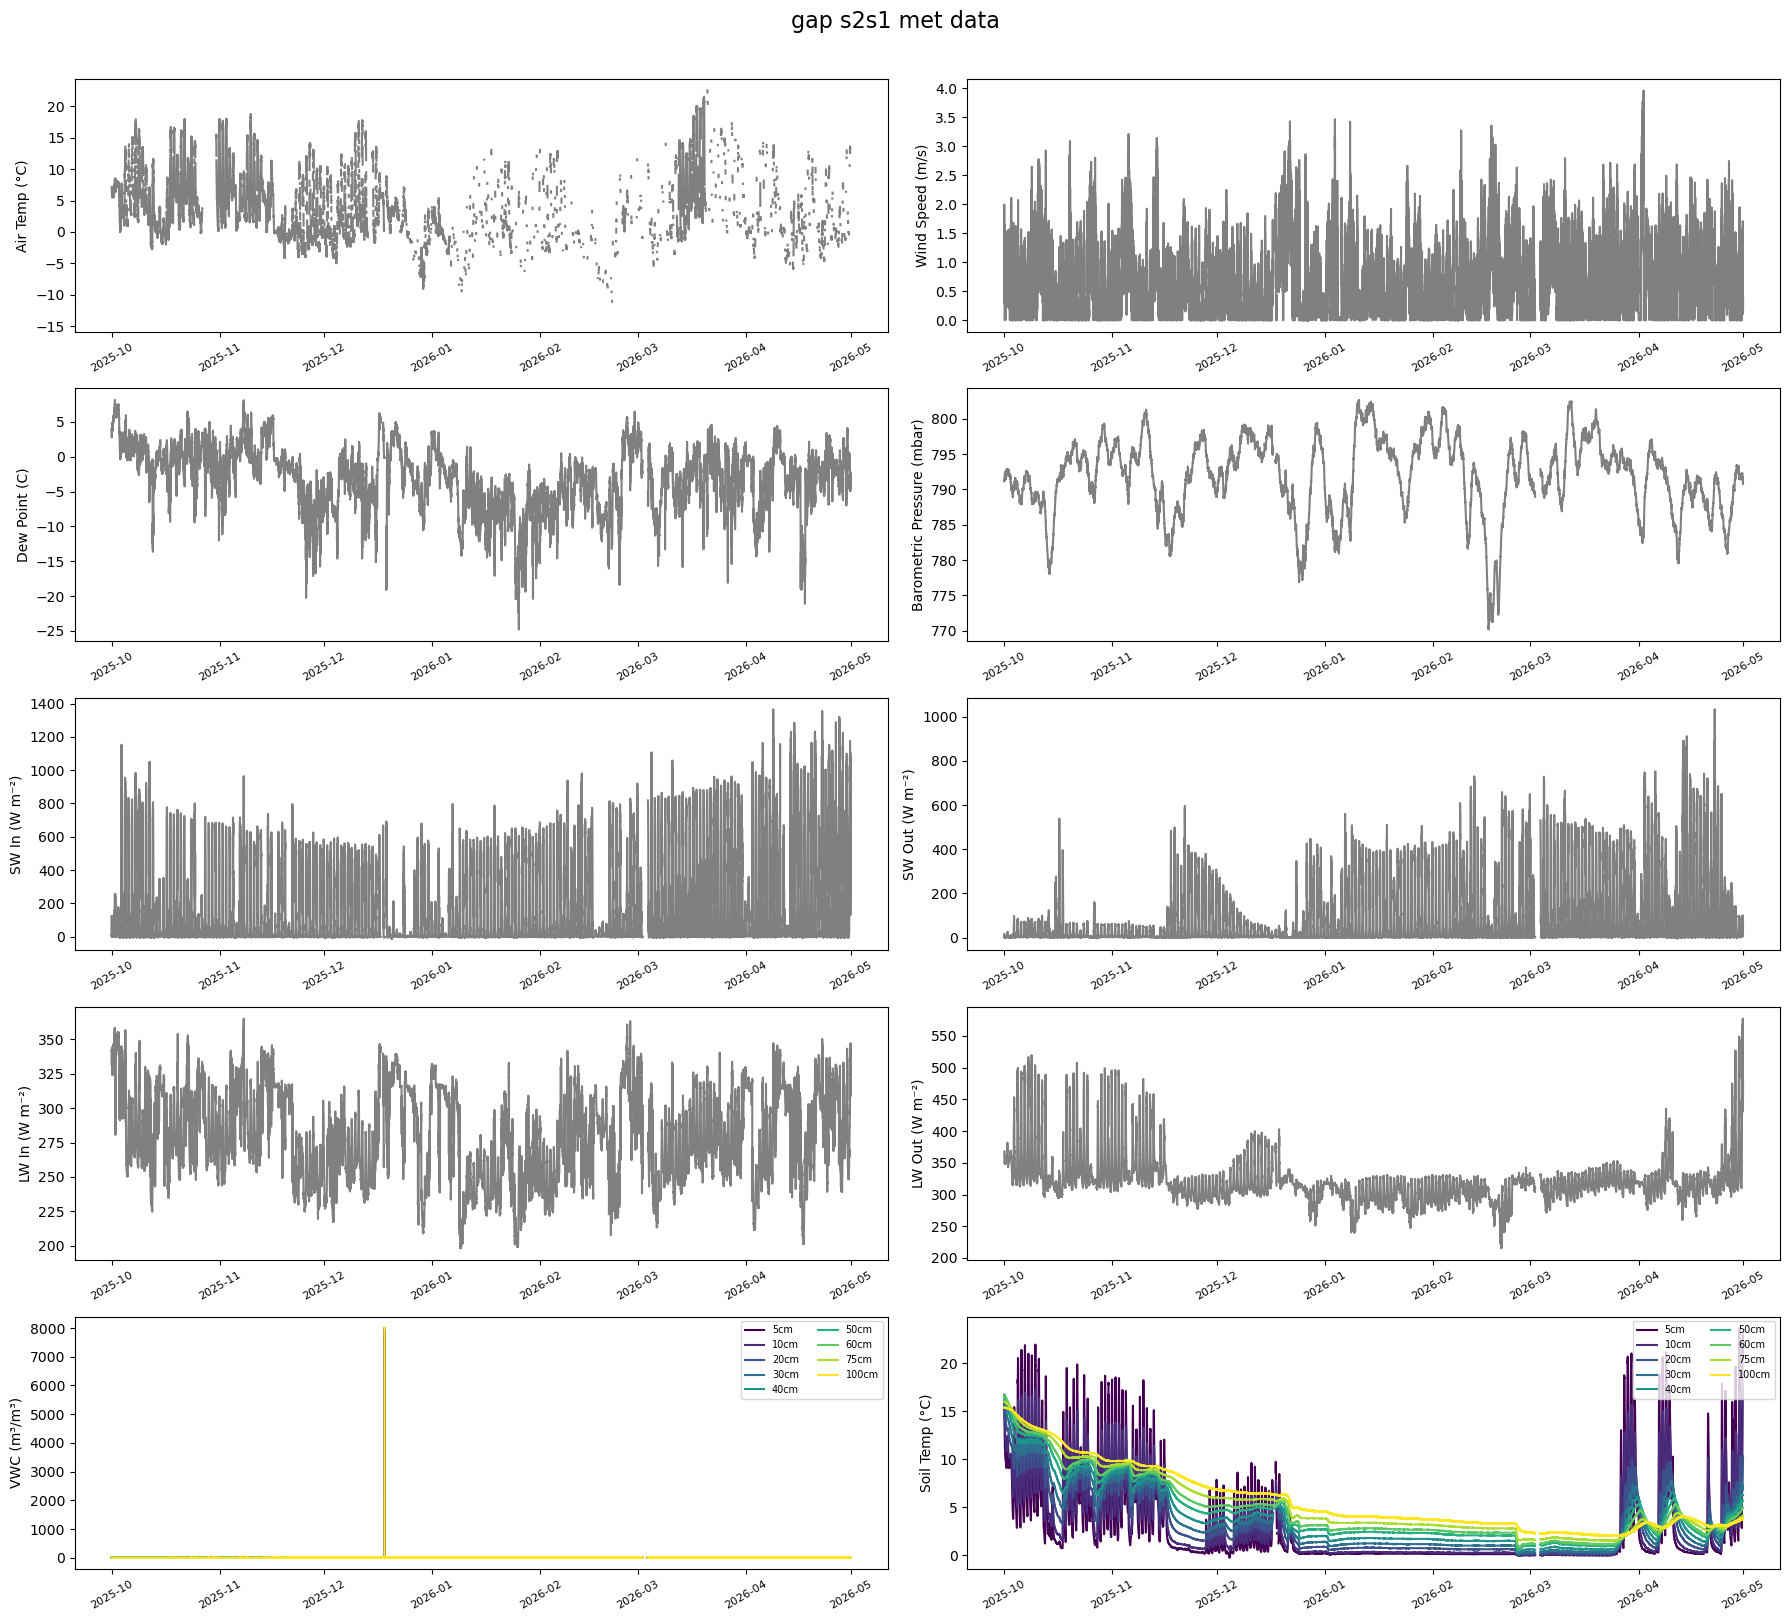

In [20]:
# specialized clean up:

# air Temp
df_met.loc[df_met['T_probe (deg C)'] < air_temp_min_c, 'T_probe (deg C)'] = np.nan

# wind speed
df_met.loc[df_met['WS_05108_mean (m/s)'] > wind_speed_max_ms, 'WS_05108_mean (m/s)'] = np.nan

# LW
# wy26 - anything >315 w/m2 make = 315?

# VWC
# wy26 clean up >1000 VWC

plot_met_overview(df_met, title='gap s2s1 met data')
# plot_met_overview(df_met, title='gap s2s1 met data', start='2025-5-20', end='2025-7-10')

# with NANs plot



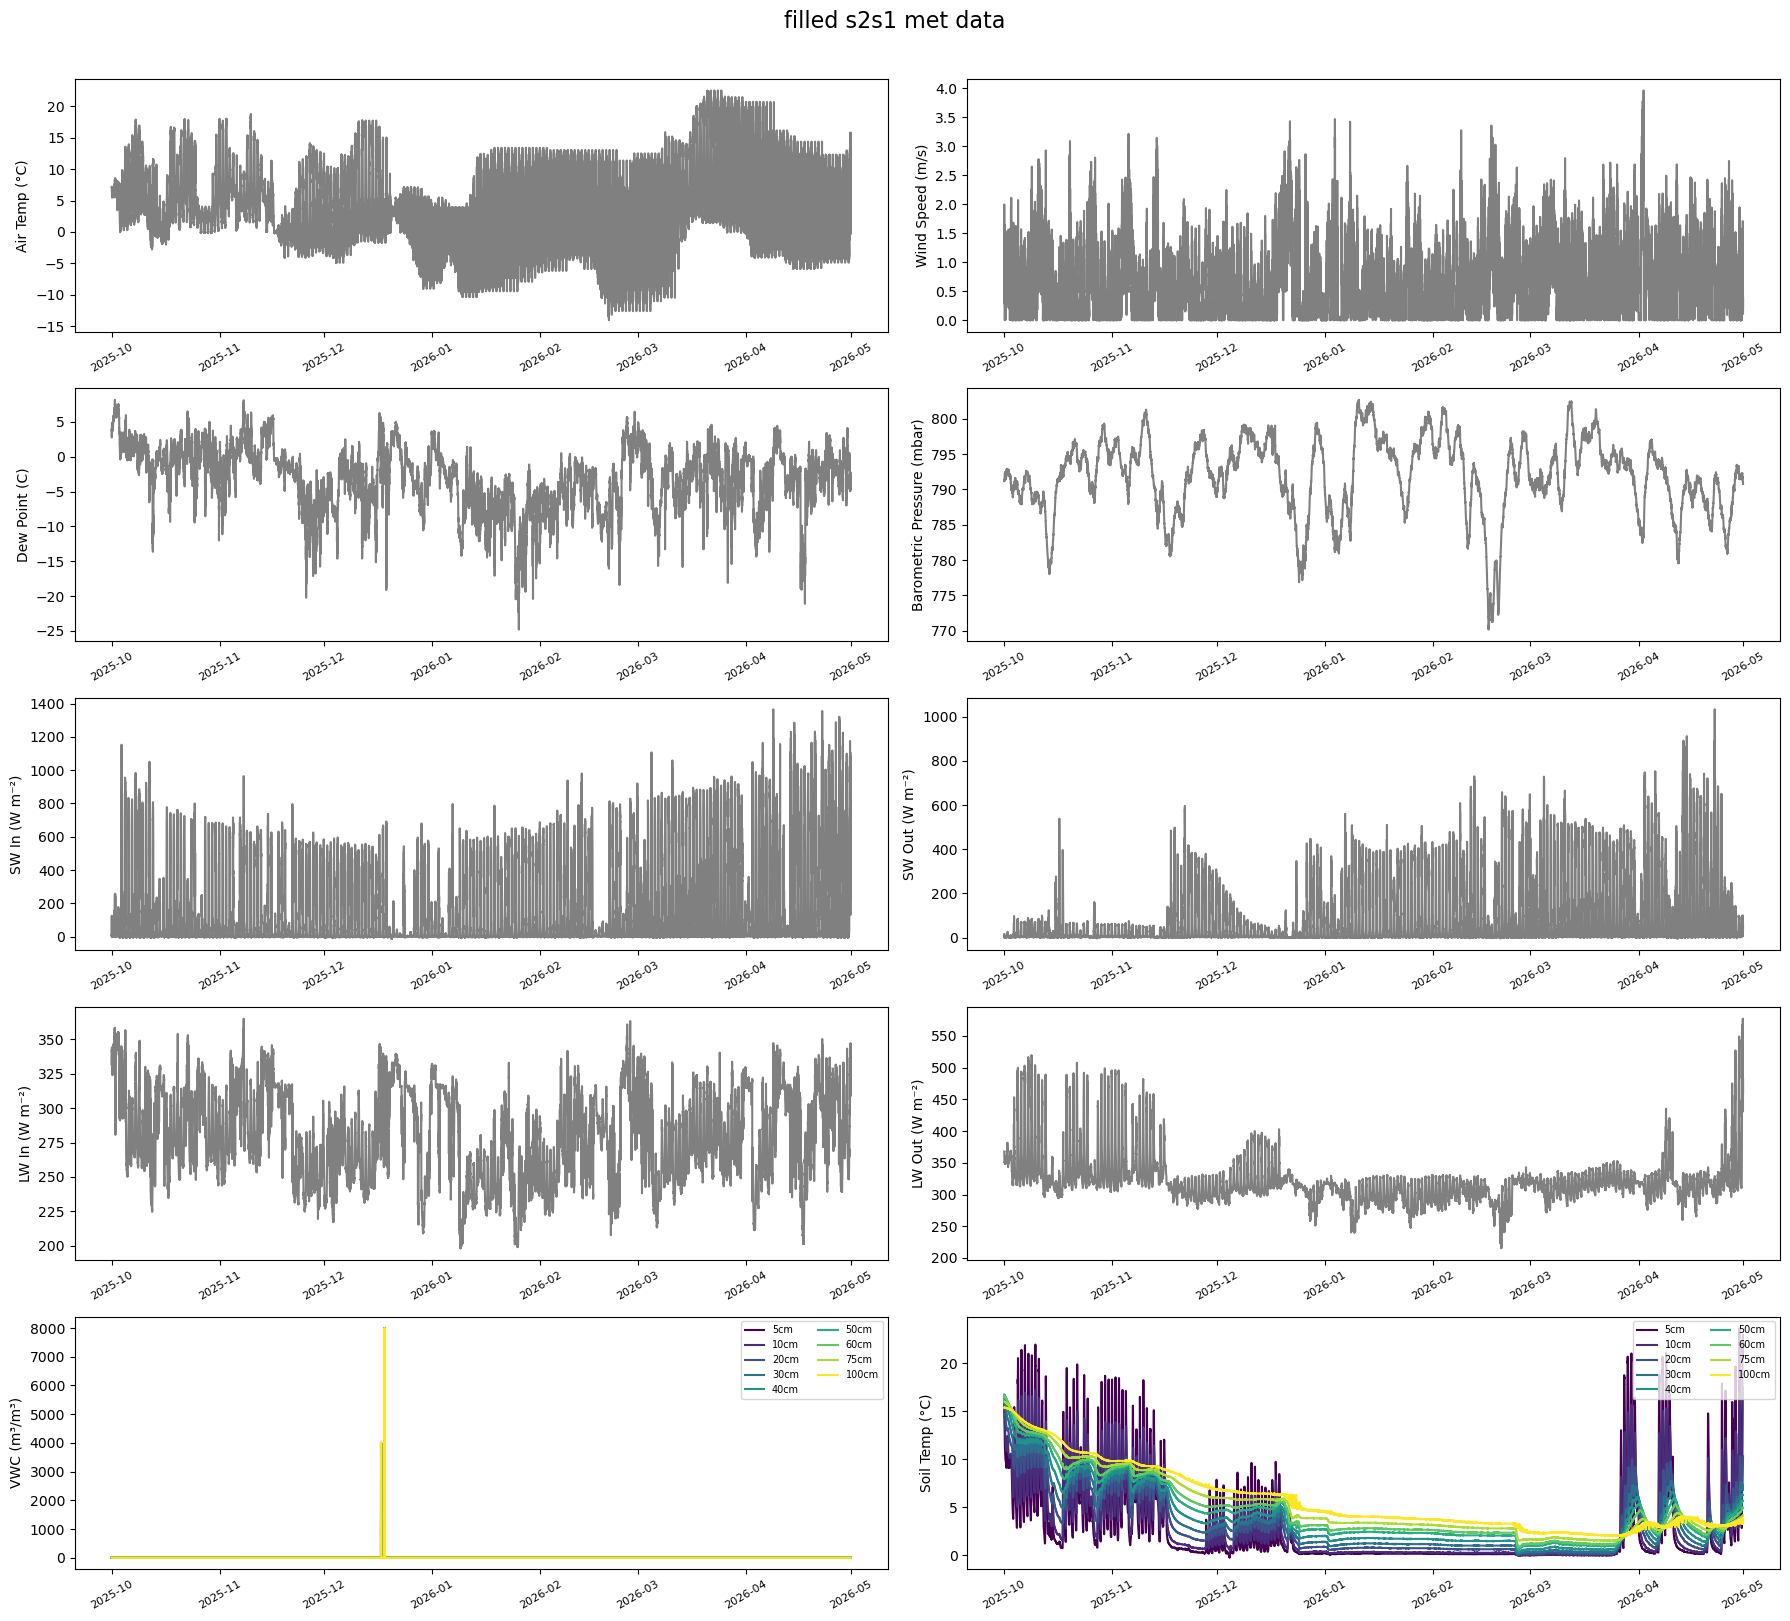

In [21]:
def diurnal_fill(series, max_days=diurnal_fill_max_days): # largest gap is 3.8 days, so 7 is conservative right now
    """Fill NaNs by looking at the same hour n days before/after, increasing n until filled."""
    filled = series.copy()
    
    for n in range(1, max_days + 1):
        nan_mask = filled.isna()
        if not nan_mask.any():
            break
        for ts in filled.index[nan_mask]:
            before = filled.get(ts - pd.Timedelta(days=n))
            after  = filled.get(ts + pd.Timedelta(days=n))
            values = [v for v in [before, after] if pd.notna(v)]
            if values:
                filled[ts] = np.mean(values)
    
    return filled

df_met = df_met.apply(lambda col: diurnal_fill(col, max_days=diurnal_fill_max_days))

plot_met_overview(df_met, title='filled s2s1 met data')
# plot_met_overview(df_met,  title='filled s2s1 met data', start='2025-5-20', end='2025-7-10')

# gapfilled plot

In [22]:
# downsample to 1 hour from 5 min, with variables of interest
df_met_1h = df_met[[
    'T_probe (deg C)', 
    'WS_05108_mean (m/s)', 
    'T_DP_Probe (deg C)',
    'BP_CS100 (mbar)',
    'R_SW_in (W m-2)', 
    'R_SW_out (W m-2)', 
    'R_LW_in (W m-2)', 
    'R_LW_out (W m-2)', 
    'T_30cm (Deg C)']].resample("1h").mean()

df_met_1h.head()



,T_probe (deg C),WS_05108_mean (m/s),T_DP_Probe (deg C),BP_CS100 (mbar),R_SW_in (W m-2),R_SW_out (W m-2),R_LW_in (W m-2),R_LW_out (W m-2),T_30cm (Deg C)
datetime,,,,,,,,,
2025-10-01 00:00:00,6.931796,1.376394,3.378712,791.250850,30.498021,5.081641,338.363533,363.051867,15.796667
2025-10-01 01:00:00,5.908318,1.137554,4.181155,791.413333,0.749681,1.613599,341.963025,354.071875,15.832500
2025-10-01 02:00:00,5.580698,0.831149,4.359375,791.651792,-1.529127,1.436978,338.554033,351.002475,15.851667
2025-10-01 03:00:00,5.777508,0.456114,4.545272,791.903800,-0.854839,1.538920,339.135833,350.686875,15.865000
2025-10-01 04:00:00,6.027785,0.367723,4.768094,792.261467,-0.808173,1.458021,338.862575,351.157017,15.842500


# Air Temp comparison
- s2s1_met_data (df_met_1h) --> CSSL/DWR HMP115A Visala @ 10 m on central tower
- s2s1_flux_data (df_flux_1h) --> CSSL/DWR IRGASON @ 1m on CHEDDAR moving arm

WY25 - there does not appear to be obvious differences or poor performence from the s2s1_met file air temp. If anything, s2s1_flux looks to be slighly warmer on avg. 

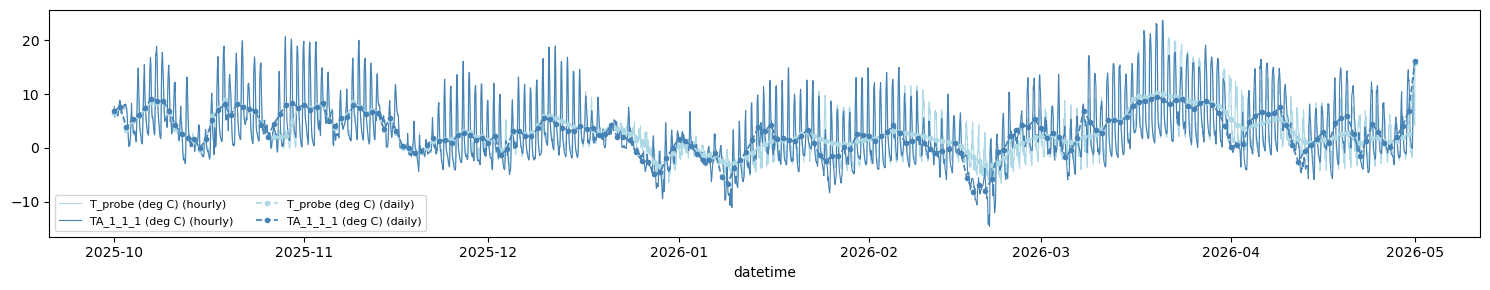

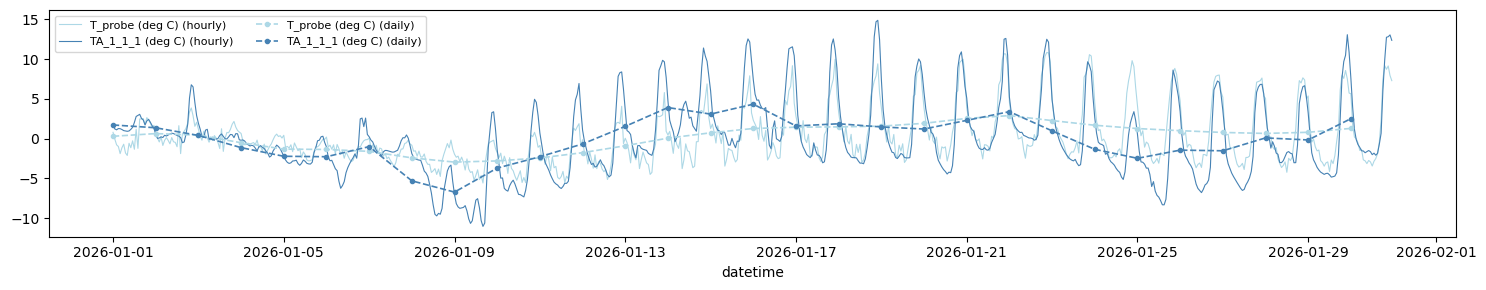

In [23]:
def plot_var_comparison(s1, s2, start=None, end=None, figsize=(15, 3)):

    if start or end:
        s1 = s1.loc[start:end]
        s2 = s2.loc[start:end]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(s1.index, s1, color='lightblue', lw=0.8, label=f'{s1.name} (hourly)')
    ax.plot(s2.index, s2, color='steelblue', lw=0.8, label=f'{s2.name} (hourly)')
    ax.plot(s1.resample('1D').mean(), color='lightblue', lw=1.2, ls='--', marker='o', ms=3, label=f'{s1.name} (daily)')
    ax.plot(s2.resample('1D').mean(), color='steelblue', lw=1.2, ls='--', marker='o', ms=3, label=f'{s2.name} (daily)')

    ax.set_xlabel('datetime')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_var_comparison(df_met_1h['T_probe (deg C)'], df_flux_1h['TA_1_1_1 (deg C)'])

# with dates
plot_var_comparison(df_met_1h['T_probe (deg C)'], df_flux_1h['TA_1_1_1 (deg C)'], start=f'{water_year}-1-01', end=f'{water_year}-1-30')

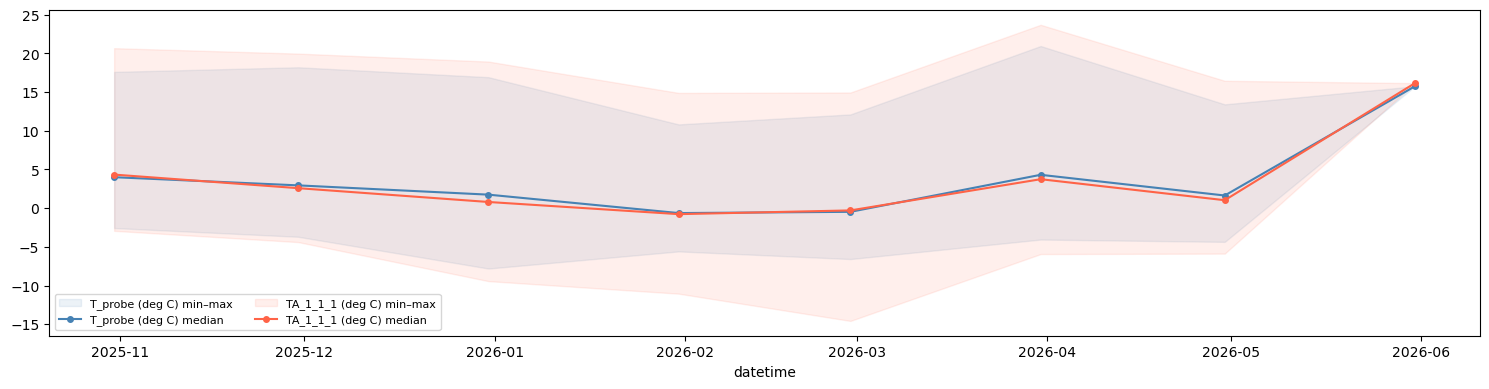

In [24]:
def var_monthly_stats(s1, s2, start=None, end=None):

    if start or end:
        s1 = s1.loc[start:end]
        s2 = s2.loc[start:end]

    fig, ax = plt.subplots(figsize=(15, 4))

    for s, color in zip([s1, s2], ['steelblue', 'tomato']):
        monthly = s.resample('1ME').agg(['min', 'median', 'max'])
        ax.fill_between(monthly.index, monthly['min'], monthly['max'], color=color, alpha=0.1, label=f'{s.name} min–max')
        ax.plot(monthly.index, monthly['median'], color=color, marker='o', ms=4, label=f'{s.name} median')

    ax.set_xlabel('datetime')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

var_monthly_stats(df_met_1h['T_probe (deg C)'], df_flux_1h['TA_1_1_1 (deg C)'])

#### cleaned dataframes
- df_prcp_1h
- df_flux_1h
- df_man_1h
- df_met_1h

In [25]:
print(df_prcp_1h.head(3))
print(df_man_1h.head(3))
print(df_flux_1h.head(3))
print(df_met_1h.head(3))

                     PREC.I-1 (in)   PRCP mm  PRCP mm incremental
datetime                                                         
2025-10-01 00:00:00             0.0     0.00                 0.00
2025-10-01 01:00:00             0.0     0.00                 0.00
2025-10-01 02:00:00             0.1     2.54                 2.54
                     Percent Snow  Snow Density
datetime                                       
2025-10-01 00:00:00           0.0           0.0
2025-10-01 01:00:00           0.0           0.0
2025-10-01 02:00:00           0.0           0.0
                     TA_1_1_1 (deg C)  e_amb (Pa)
datetime                                         
2025-10-01 00:00:00          7.698746   640.36880
2025-10-01 01:00:00          6.784641   623.37535
2025-10-01 02:00:00          5.927071   635.96040
                     T_probe (deg C)  WS_05108_mean (m/s)  T_DP_Probe (deg C)  \
datetime                                                                        
2025-10-01 00:00:0

#### Merge data

In [26]:
# concat dataframes

df = pd.concat([df_prcp_1h, df_man_1h, df_flux_1h, df_met_1h], axis=1)

# print shape of df
print(df.shape)

# count nulls/col, want 0's here
print(df.isnull().sum())


(5089, 16)
PREC.I-1 (in)          1
PRCP mm                0
PRCP mm incremental    0
Percent Snow           0
Snow Density           0
TA_1_1_1 (deg C)       0
e_amb (Pa)             0
T_probe (deg C)        0
WS_05108_mean (m/s)    0
T_DP_Probe (deg C)     0
BP_CS100 (mbar)        0
R_SW_in (W m-2)        0
R_SW_out (W m-2)       0
R_LW_in (W m-2)        0
R_LW_out (W m-2)       0
T_30cm (Deg C)         0
dtype: int64


#### Compute variables (from cleaned hourly)
- Net Solar
- Precip Temp (i.e. Wet Bulb temperature)

In [27]:
# compute Net Radation
df["Net_solar (W m-2)"] = df["R_SW_in (W m-2)"] - df["R_SW_out (W m-2)"]

from metpy.units import units
# compute Precip Temp (wet bulb temp)
pressure    = df["BP_CS100 (mbar)"].values * units.mbar
temperature = df["T_probe (deg C)"].values * units.degC
dewpoint    = df["T_DP_Probe (deg C)"].values * units.degC

df["Precip_Temp (deg C)"] = wet_bulb_temperature(pressure, temperature, dewpoint).to("degC").magnitude


### Vars to keep and renamed

See config file to get list of names

In [28]:
# Rename columns
df = df.rename(columns=rename_pointSnobal)

# Keep only renamed columns
df = df[list(rename_pointSnobal.values())]

# Check
print(df.columns)

df.info()

Index(['air_temp', 'percent_snow', 'precip', 'precip_temp', 'snow_density',
       'vapor_pressure', 'wind_speed', 'soil_temp', 'net_solar', 'thermal'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5089 entries, 2025-10-01 00:00:00 to 2026-05-01 00:00:00
Freq: h
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_temp        5089 non-null   float64
 1   percent_snow    5089 non-null   float64
 2   precip          5089 non-null   float64
 3   precip_temp     5089 non-null   float64
 4   snow_density    5089 non-null   float64
 5   vapor_pressure  5089 non-null   float64
 6   wind_speed      5089 non-null   float64
 7   soil_temp       5089 non-null   float64
 8   net_solar       5089 non-null   float64
 9   thermal         5089 non-null   float64
dtypes: float64(10)
memory usage: 437.3 KB


### Plot all Vars to keep

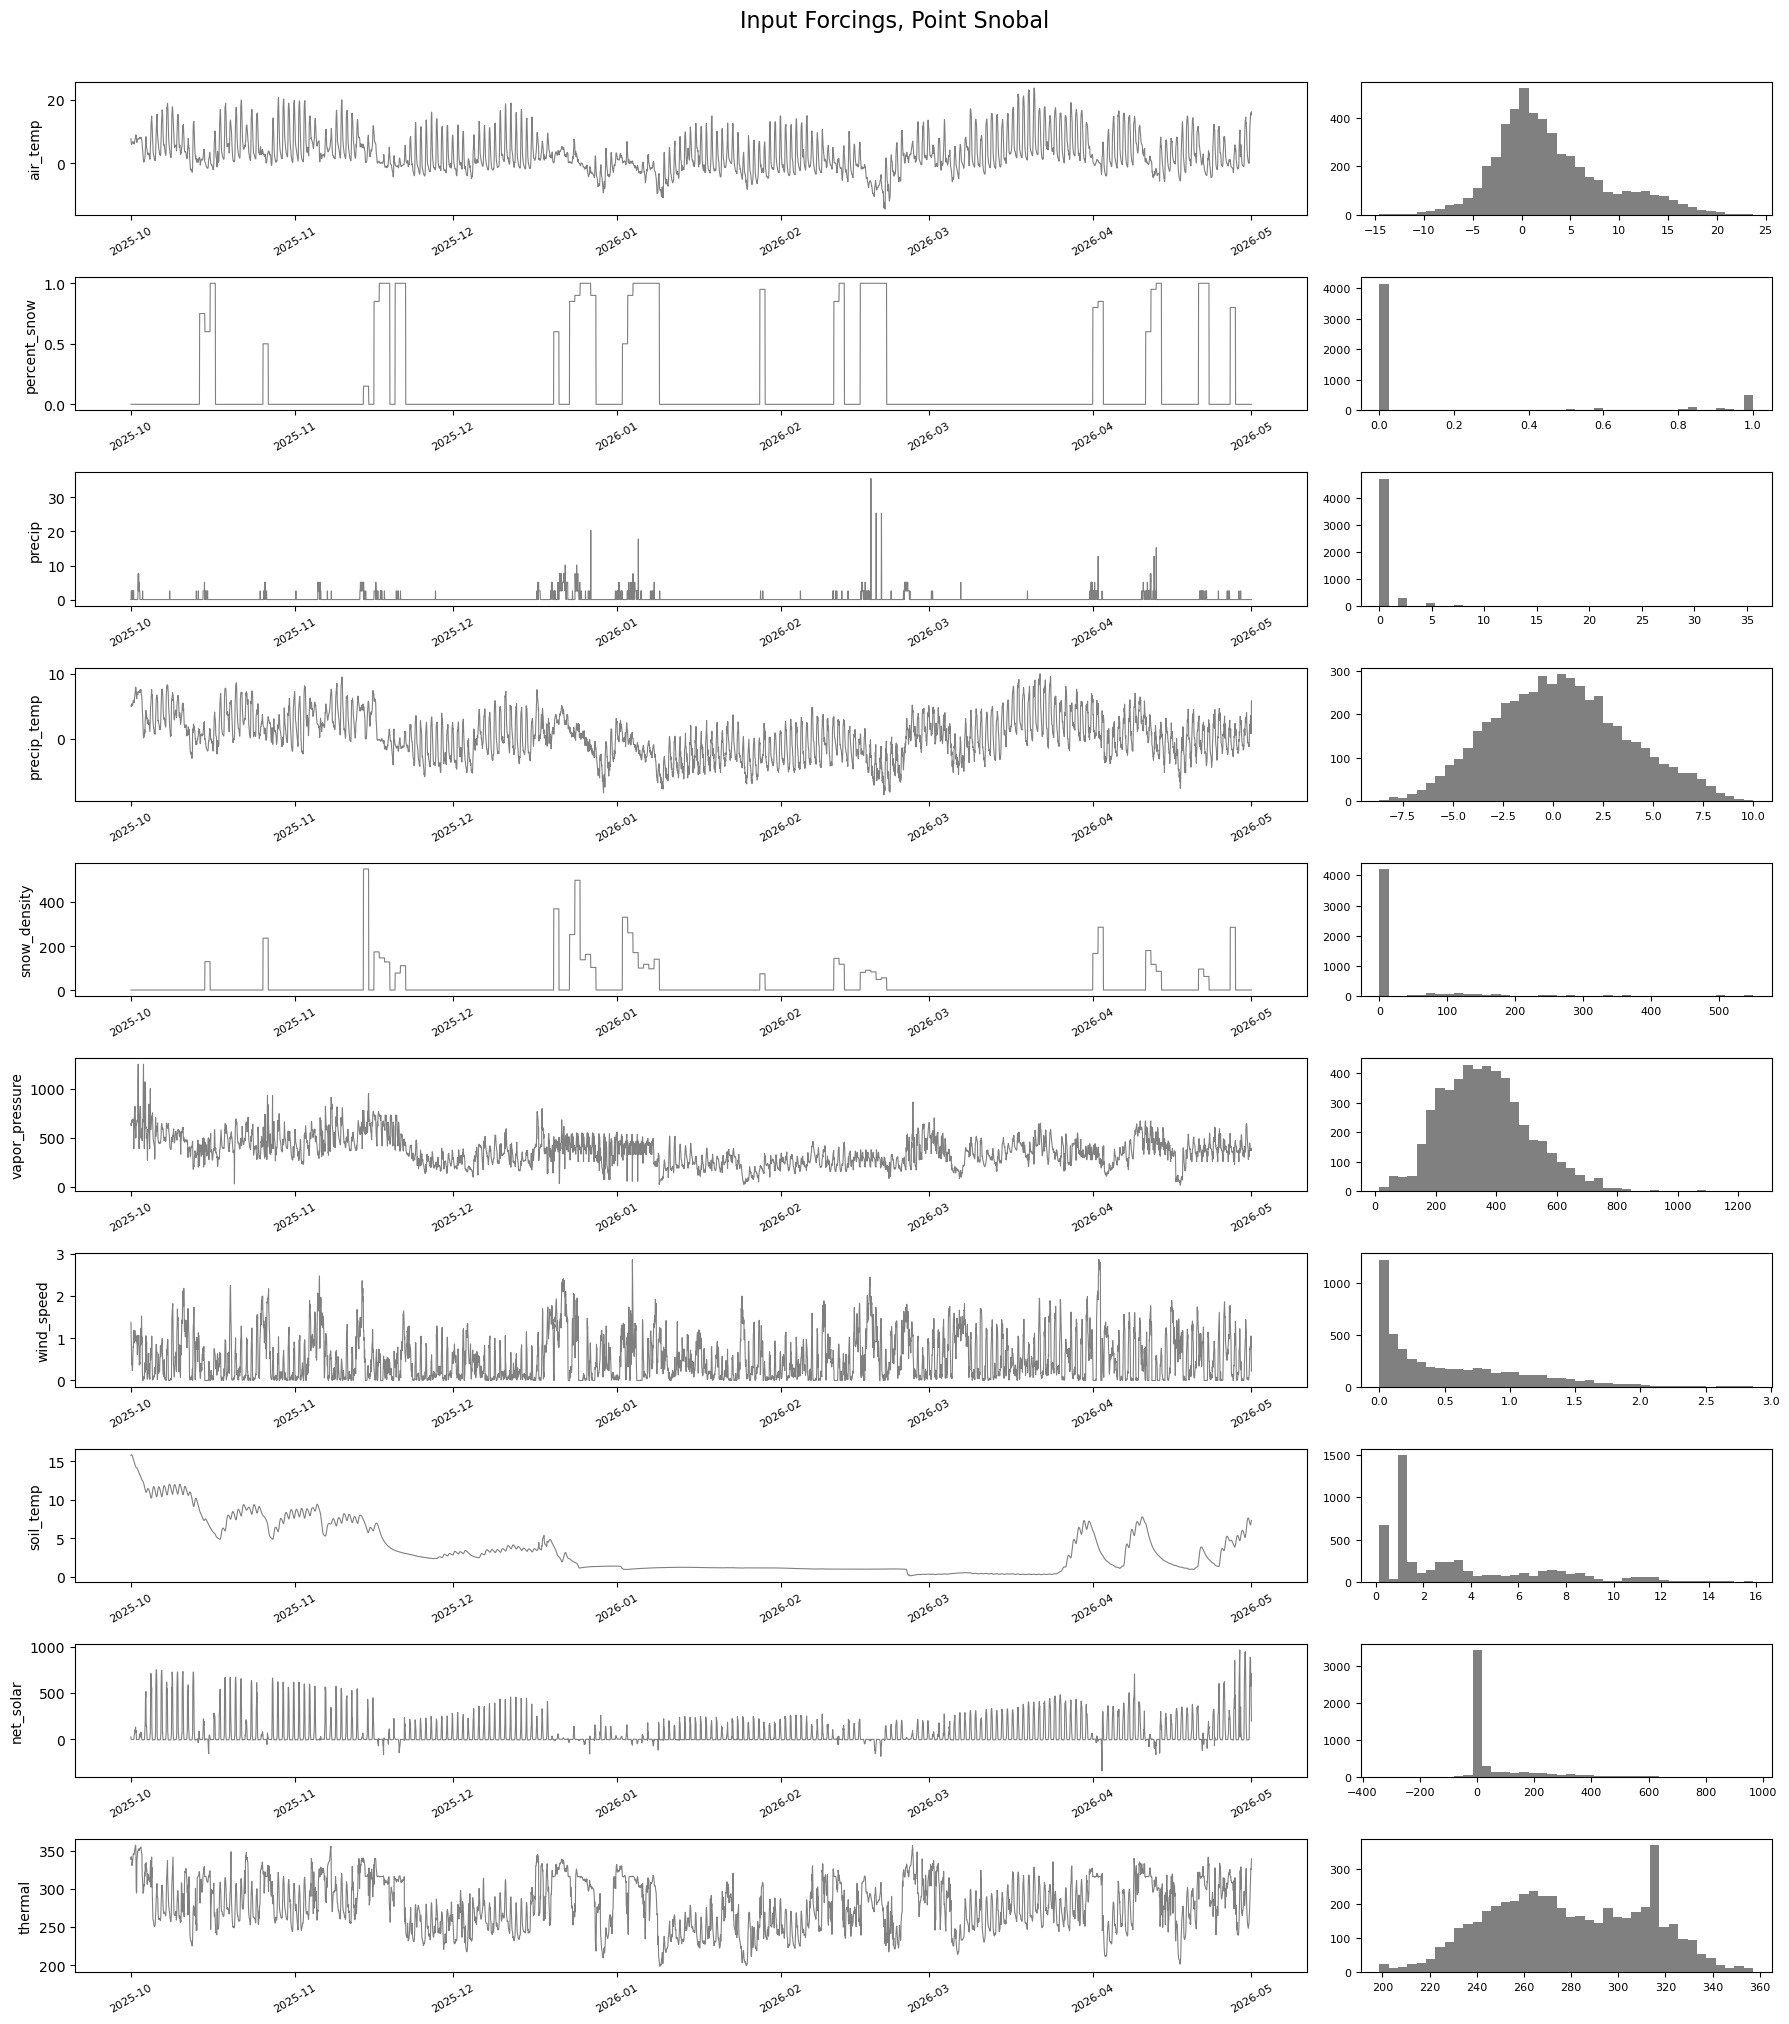

In [29]:
import matplotlib.gridspec as gridspec

def plot_met_final(df, title, start=None, end=None):
    if start is not None or end is not None:
        df = df.loc[start:end]

    cols = list(df.columns)
    n = len(cols)

    fig = plt.figure(figsize=(18, n * 2))
    gs = gridspec.GridSpec(n, 2, width_ratios=[3, 1], figure=fig)

    for i, col in enumerate(cols):
        ax_line = fig.add_subplot(gs[i, 0])
        ax_hist = fig.add_subplot(gs[i, 1])

        # Line plot
        ax_line.plot(df.index, df[col], color='gray', linewidth=0.8)
        ax_line.set_ylabel(col)
        ax_line.set_xlabel('')
        ax_line.tick_params(axis='x', labelrotation=30, labelsize=8)

        # Histogram
        ax_hist.hist(df[col].dropna(), bins=40, color='gray', edgecolor='none', orientation='vertical')
        ax_hist.set_ylabel('')
        ax_hist.set_xlabel('')
        ax_hist.tick_params(labelsize=8)

    plt.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()

    return fig
   

fig = plot_met_final(df, title='Input Forcings, Point Snobal')
fig.savefig(fig_pointSnobal.joinpath(out_file_pointSnobal), dpi=300, bbox_inches="tight")
plt.show()

# fig = plot_met_final(df, title='Final Met Data', start=f'{water_year}-06-15', end=f'{water_year}-06-30')
# plt.show()

In [30]:
# monthly quick look
monthly = df.resample('ME').mean().round(2)
print(monthly.to_string())

            air_temp  percent_snow  precip  precip_temp  snow_density  vapor_pressure  wind_speed  soil_temp  net_solar  thermal
datetime                                                                                                                        
2025-10-31      5.79          0.09    0.17         2.71         11.77          481.02        0.52       9.14     102.62   291.08
2025-11-30      3.82          0.17    0.26         1.31         39.49          453.46        0.47       5.44      53.76   285.20
2025-12-31      1.62          0.17    0.54         0.03         49.09          346.07        0.50       2.82      36.16   277.43
2026-01-31      0.06          0.24    0.24        -2.35         41.54          261.05        0.46       1.17      27.42   261.16
2026-02-28      0.09          0.24    0.40        -1.47         22.02          287.16        0.58       0.92      26.62   277.03
2026-03-31      5.75          0.00    0.06         1.92          0.00          356.95        0.61

In [31]:
# Let's save the merged dataframe with all forcing data we need to run iSnobal
df.to_csv(out_pointSnobal.joinpath(out_file_pointSnobal), float_format='%.1f')

### PySnobal
column names are modified to include units.

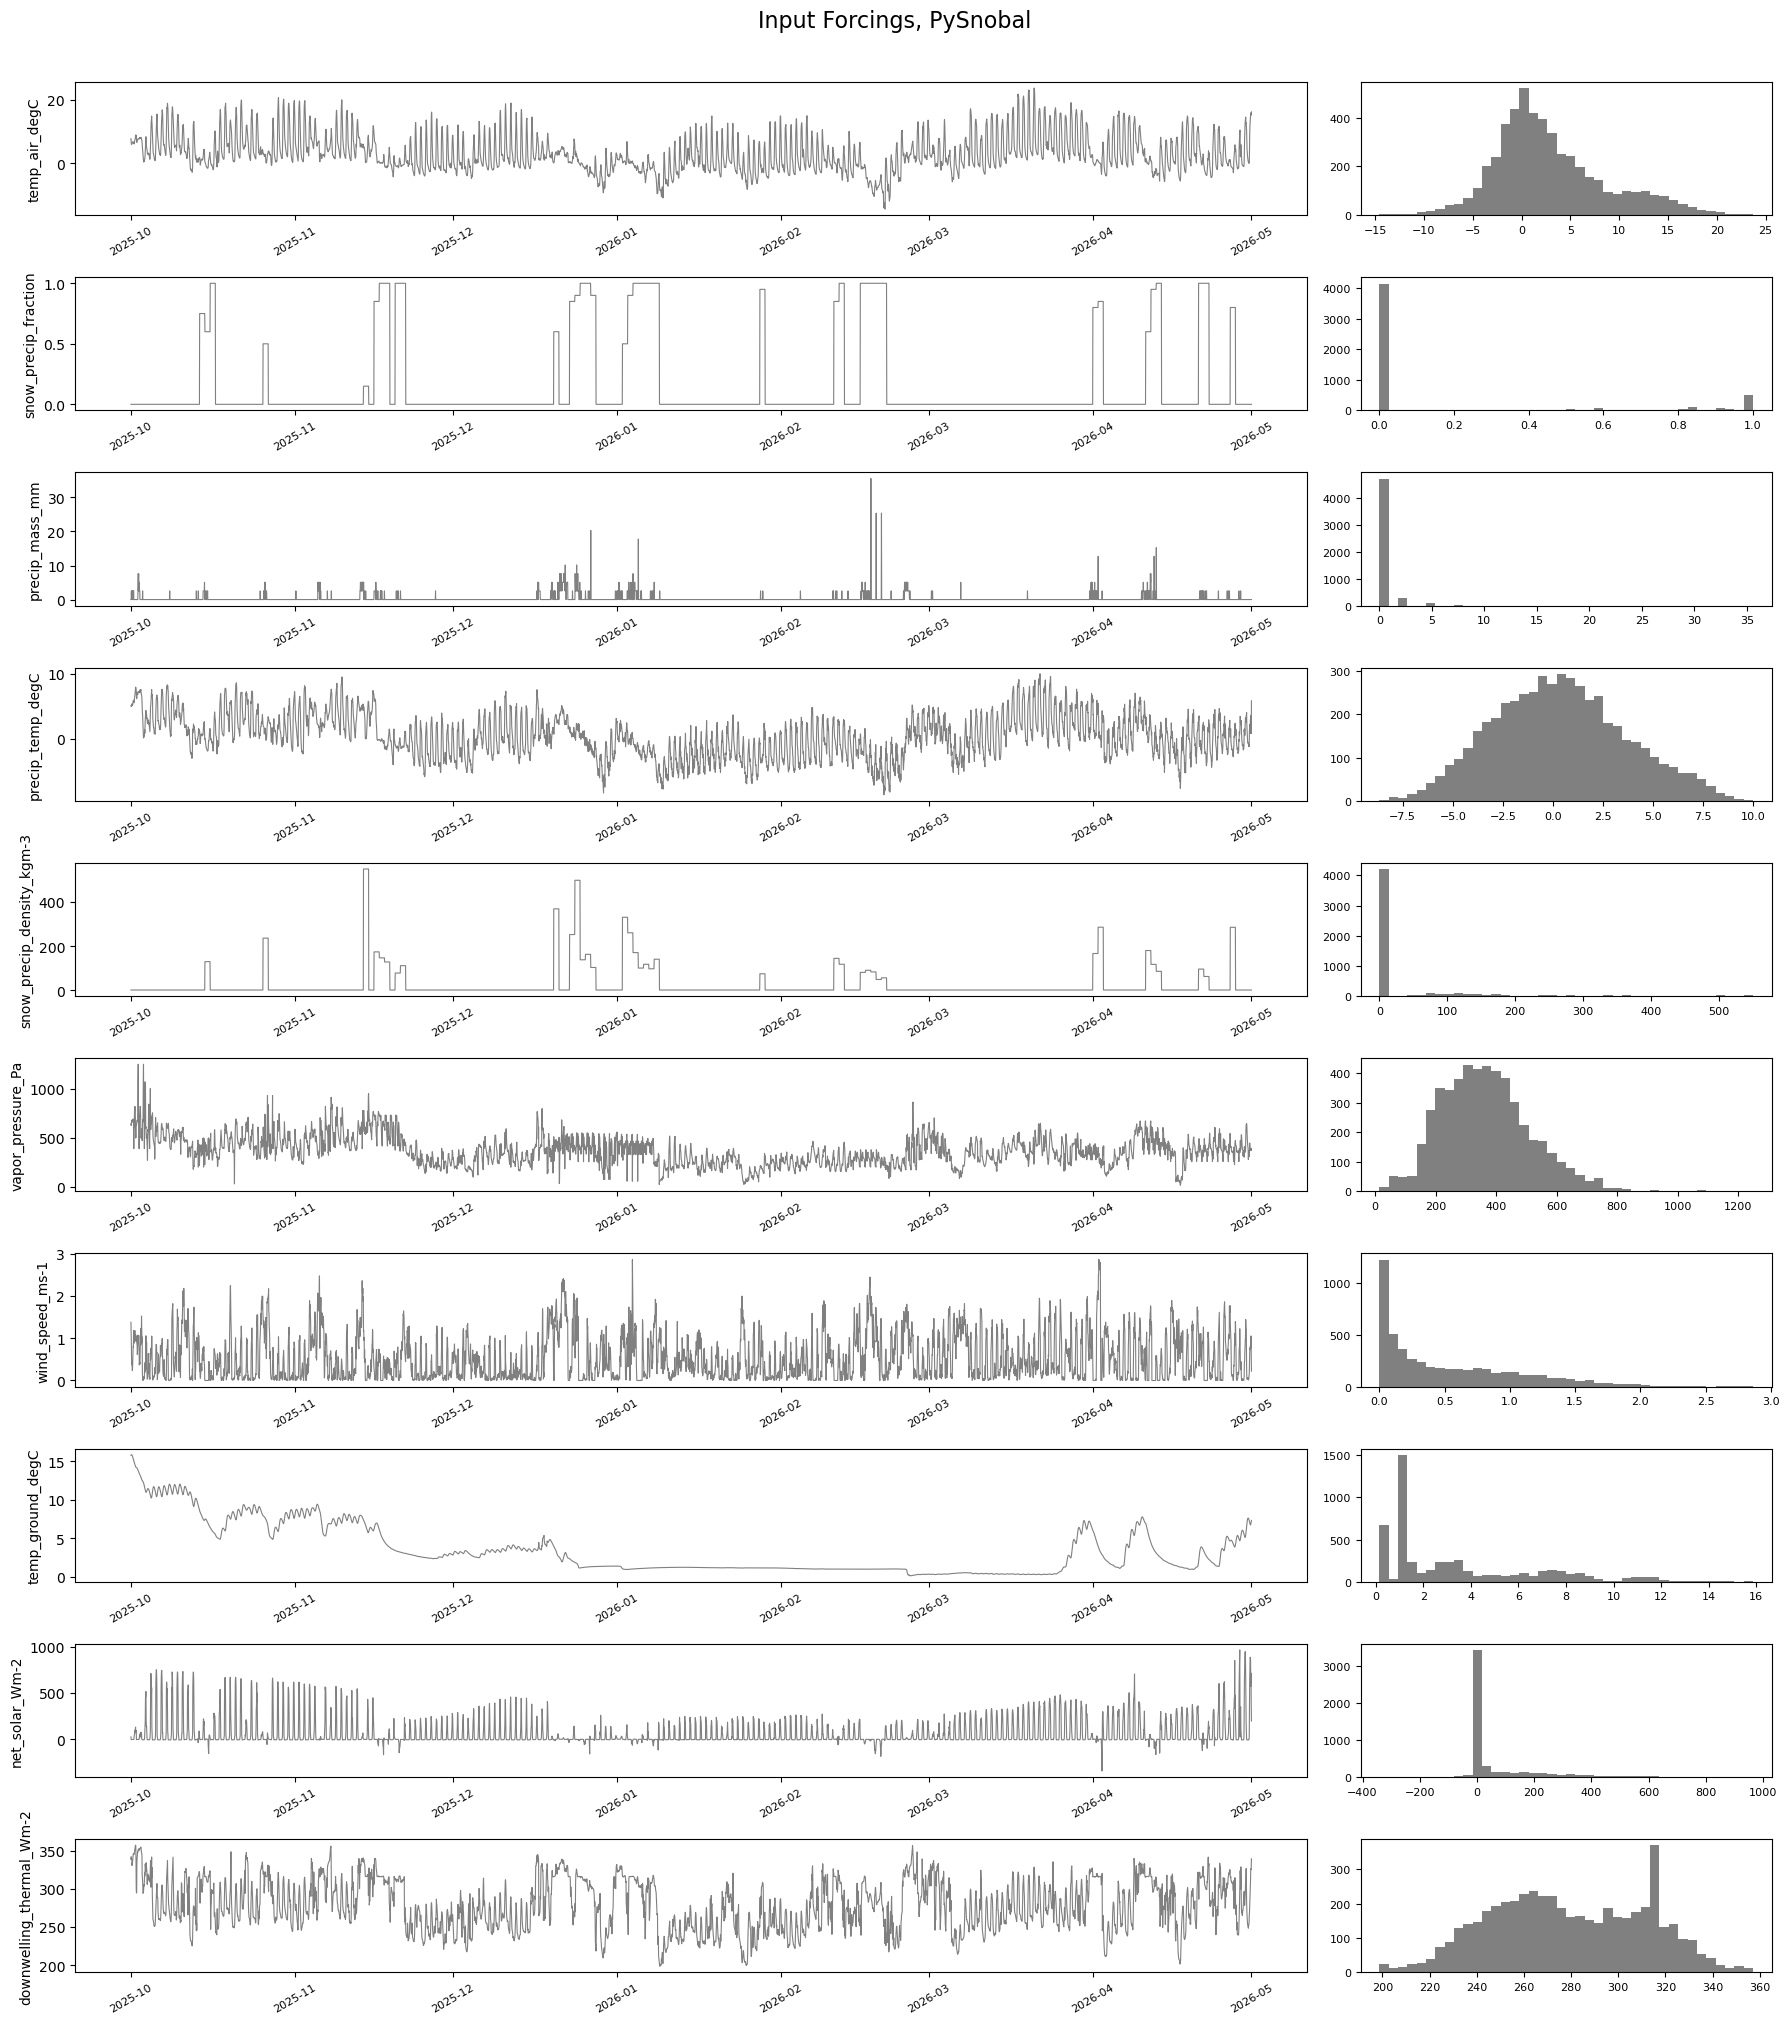

In [32]:
# rename cols and save for pySnobal 
df_pySnobal = df.copy()

# Rename columns
df_pySnobal = df_pySnobal.rename(columns=rename_pySnobal)

fig = plot_met_final(df_pySnobal, title='Input Forcings, PySnobal')
fig.savefig(fig_pySnobal.joinpath(out_file_pySnobal), dpi=300, bbox_inches="tight")
plt.show()

# fig = plot_met_final(df, title='Final Met Data', start=f'{water_year}-06-15', end=f'{water_year}-06-30')
# plt.show()


# Let's save the merged dataframe with all forcing data we need to run iSnobal
df_pySnobal.to_csv(out_pySnobal.joinpath(out_file_pySnobal), float_format='%.1f')
